<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB15(13).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 13

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Normal comments
normal = [
    "I love this product, it works great!",
    "Have a wonderful day everyone",
    "This is a really helpful tutorial",
    "Thanks for sharing this information",
    "Great job on the project",
    "I really enjoyed reading this article",
    "You did an amazing work here",
    "This is so beautiful and creative",
    "I appreciate your kindness and effort",
    "Looking forward to the next post",
    "This made my day, thank you",
    "Excellent explanation, very clear",
    "Wonderful content as always",
    "Keep up the great work friend",
    "Very informative and well written",
    "I learned so much from this",
    "Such a positive and helpful post",
    "You are very talented and creative",
    "This is exactly what I needed",
    "Best tutorial I have seen today",
    "Really nice work on this project",
    "Thank you for being so helpful",
    "This community is so supportive",
    "I enjoy reading your content daily",
    "Fantastic explanation of the topic",
]

# Toxic comments
toxic = [
    "You are so stupid and useless",
    "I hate you, go away forever",
    "This is the worst garbage ever",
    "You are an idiot and a loser",
    "Nobody likes you, just disappear",
    "This is complete trash and worthless",
    "You are dumb and incompetent",
    "I want you to shut up forever",
    "You are pathetic and disgusting",
    "This is absolute garbage content",
    "You should be ashamed of yourself",
    "What a moron writing this stuff",
    "You are the worst person ever",
    "This is so bad it hurts my eyes",
    "You are a complete failure always",
    "Stop posting this awful content",
    "You have no idea what you are doing",
    "This is pure nonsense and stupid",
    "You are so annoying and terrible",
    "I despise everything about this",
    "What an absolute waste of time",
    "You are worthless and disgusting",
    "This content is trash and horrible",
    "You are an embarrassment to everyone",
    "Stop being so dumb and useless",
]

# Combine
texts  = normal + toxic
labels = [0] * len(normal) + [1] * len(toxic)   # 0=normal, 1=toxic

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Total samples : {len(df)}")
print(f"Normal (0)    : {sum(df.label==0)}")
print(f"Toxic  (1)    : {sum(df.label==1)}")
print("\nSample rows:")
print(df.head(6).to_string())

Total samples : 50
Normal (0)    : 25
Toxic  (1)    : 25

Sample rows:
                                   text  label
0         Keep up the great work friend      0
1     You are a complete failure always      1
2  This is complete trash and worthless      1
3        What an absolute waste of time      1
4    You are very talented and creative      0
5  You are an embarrassment to everyone      1


In [ ]:
VOCAB_SIZE = 2000    # max unique words to keep
MAX_LEN    = 20      # max words per comment (pad/truncate to this)
EMBED_DIM  = 32      # embedding vector size per word

# Tokenizer: builds word → integer dictionary
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

# Convert text to integer sequences
sequences = tokenizer.texts_to_sequences(df["text"])

# Pad all sequences to same length
padded = pad_sequences(sequences, maxlen=MAX_LEN,
                        padding='post', truncating='post')

print("Vocabulary size :", len(tokenizer.word_index))
print("Padded shape    :", padded.shape)   # (50, 20)

# Show example
example = df["text"][0]
print(f"\nOriginal : {example}")
print(f"Sequence : {sequences[0]}")
print(f"Padded   : {padded[0]}")

Vocabulary size : 139
Padded shape    : (50, 20)

Original : Keep up the great work friend
Sequence : [53, 22, 9, 14, 15, 54]
Padded   : [53 22  9 14 15 54  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [ ]:
# Show what tokenizer learned
word_index = tokenizer.word_index
print("Word → Integer mapping (first 20 words):")
print("-" * 35)
for word, idx in list(word_index.items())[:20]:
    print(f"  {word:<15} → {idx}")

print(f"\nEach word will be mapped to a {EMBED_DIM}-dim vector")
print("Similar words (hate, awful, terrible) will cluster together")
print("after training — that's how embeddings capture meaning!")

Word → Integer mapping (first 20 words):
-----------------------------------
  <OOV>           → 1
  you             → 2
  this            → 3
  and             → 4
  are             → 5
  is              → 6
  i               → 7
  so              → 8
  the             → 9
  a               → 10
  content         → 11
  what            → 12
  an              → 13
  great           → 14
  work            → 15
  of              → 16
  very            → 17
  to              → 18
  have            → 19
  helpful         → 20

Each word will be mapped to a 32-dim vector
Similar words (hate, awful, terrible) will cluster together
after training — that's how embeddings capture meaning!


In [ ]:
X = padded
y = np.array(df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")   # (40, 20)
print(f"X_test  : {X_test.shape}")    # (10, 20)
print(f"Train toxic ratio : {y_train.mean():.0%}")
print(f"Test  toxic ratio : {y_test.mean():.0%}")

X_train : (40, 20)
X_test  : (10, 20)
Train toxic ratio : 50%
Test  toxic ratio : 50%


In [ ]:
def build_lstm():
    model = models.Sequential([
        # Embedding: integer → dense vector
        layers.Embedding(VOCAB_SIZE, EMBED_DIM,
                         input_length=MAX_LEN),

        # LSTM reads word vectors left to right
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')  # 0=normal 1=toxic
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_gru():
    model = models.Sequential([
        layers.Embedding(VOCAB_SIZE, EMBED_DIM,
                         input_length=MAX_LEN),

        # GRU: faster and lighter than LSTM, often same accuracy
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

gru_model = build_gru()
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)
print(f"LSTM final train acc: "
      f"{lstm_history.history['accuracy'][-1]:.2%}")

print("\nTraining GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)
print(f"GRU  final train acc: "
      f"{gru_history.history['accuracy'][-1]:.2%}")

Training LSTM...
LSTM final train acc: 97.22%

Training GRU...
GRU  final train acc: 52.78%


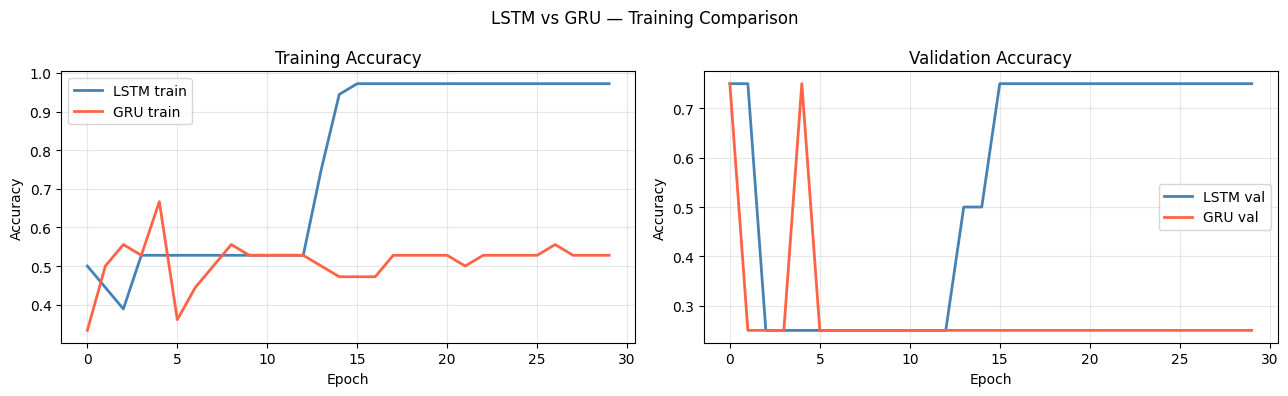

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(lstm_history.history['accuracy'],
         label='LSTM train', color='steelblue', linewidth=2)
ax1.plot(gru_history.history['accuracy'],
         label='GRU train',  color='tomato',    linewidth=2)
ax1.set_title('Training Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(lstm_history.history['val_accuracy'],
         label='LSTM val', color='steelblue', linewidth=2)
ax2.plot(gru_history.history['val_accuracy'],
         label='GRU val',  color='tomato',    linewidth=2)
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM vs GRU — Training Comparison', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
print("=" * 45)

# LSTM evaluation
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
lstm_preds = (lstm_model.predict(X_test, verbose=0) > 0.5).astype(int)

print(f"LSTM  →  Loss: {lstm_loss:.4f}  |  Accuracy: {lstm_acc:.2%}")
print("\nLSTM Classification Report:")
print(classification_report(y_test, lstm_preds,
                             target_names=["Normal","Toxic"]))

# GRU evaluation
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)
gru_preds = (gru_model.predict(X_test, verbose=0) > 0.5).astype(int)

print("=" * 45)
print(f"GRU   →  Loss: {gru_loss:.4f}  |  Accuracy: {gru_acc:.2%}")
print("\nGRU Classification Report:")
print(classification_report(y_test, gru_preds,
                             target_names=["Normal","Toxic"]))

LSTM  →  Loss: 1.0688  |  Accuracy: 80.00%

LSTM Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      0.80      0.80         5
       Toxic       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

GRU   →  Loss: 0.6952  |  Accuracy: 50.00%

GRU Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         5
       Toxic       0.50      1.00      0.67         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


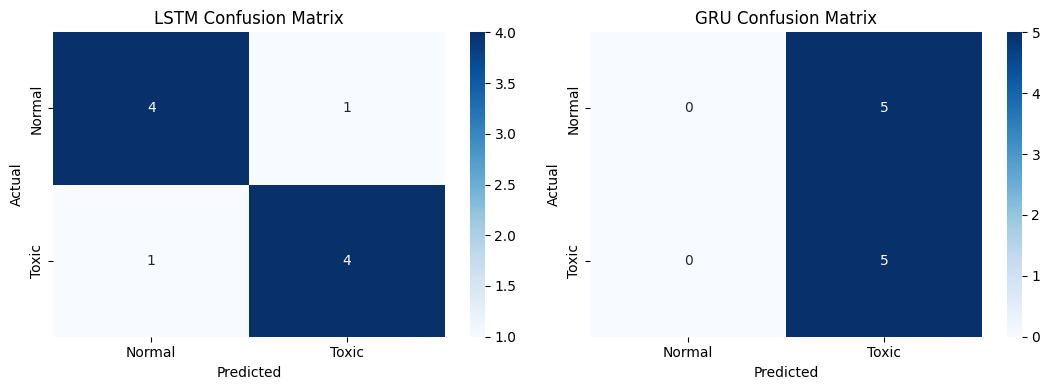

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in [
    (ax1, lstm_preds, "LSTM"),
    (ax2, gru_preds,  "GRU")
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Normal","Toxic"],
                yticklabels=["Normal","Toxic"], ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout(); plt.show()

In [ ]:
def predict_comment(text, model, label="Model"):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN,
                        padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)[0][0]
    verdict = "TOXIC 🚨" if prob > 0.5 else "Normal ✅"
    print(f"[{label}] '{text}'")
    print(f"  → {verdict}  (confidence: {prob:.2%})\n")

# Try your own comments!
test_comments = [
    "You are so stupid and terrible",
    "Thank you for the helpful post",
    "I hate everything about this",
    "This is a great explanation",
    "You are worthless and disgusting",
]

print("LSTM Predictions:")
print("-" * 50)
for c in test_comments:
    predict_comment(c, lstm_model, "LSTM")

print("GRU Predictions:")
print("-" * 50)
for c in test_comments:
    predict_comment(c, gru_model, "GRU")

LSTM Predictions:
--------------------------------------------------
[LSTM] 'You are so stupid and terrible'
  → TOXIC 🚨  (confidence: 95.56%)

[LSTM] 'Thank you for the helpful post'
  → TOXIC 🚨  (confidence: 95.51%)

[LSTM] 'I hate everything about this'
  → TOXIC 🚨  (confidence: 95.46%)

[LSTM] 'This is a great explanation'
  → Normal ✅  (confidence: 0.06%)

[LSTM] 'You are worthless and disgusting'
  → TOXIC 🚨  (confidence: 95.56%)

GRU Predictions:
--------------------------------------------------
[GRU] 'You are so stupid and terrible'
  → TOXIC 🚨  (confidence: 53.21%)

[GRU] 'Thank you for the helpful post'
  → TOXIC 🚨  (confidence: 53.19%)

[GRU] 'I hate everything about this'
  → TOXIC 🚨  (confidence: 53.20%)

[GRU] 'This is a great explanation'
  → TOXIC 🚨  (confidence: 53.20%)

[GRU] 'You are worthless and disgusting'
  → TOXIC 🚨  (confidence: 53.21%)

